# Classification

In [1]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_dir = '/content/'

# Load saved splits
X_train = pd.read_csv(data_dir + 'X_clf_train.csv')
X_test  = pd.read_csv(data_dir + 'X_clf_test.csv')
y_train = pd.read_csv(data_dir + 'y_clf_train.csv').squeeze()
y_test  = pd.read_csv(data_dir + 'y_clf_test.csv').squeeze()

print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("Class balance (train):\n", y_train.value_counts(normalize=True))

Shapes: (7200, 27) (1800, 27) (7200,) (1800,)
Class balance (train):
 placed
1    0.855833
0    0.144167
Name: proportion, dtype: float64


In [4]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    # Cross-val on training data
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=skf,
                                scoring='f1', n_jobs=-1)

    # Fit on full training set & predict on test
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    return {
        'Model':      name,
        'CV F1 (mean)': round(cv_scores.mean(), 4),
        'CV F1 (std)':  round(cv_scores.std(), 4),
        'Accuracy':   round(accuracy_score(y_te, y_pred), 4),
        'Precision':  round(precision_score(y_te, y_pred), 4),
        'Recall':     round(recall_score(y_te, y_pred), 4),
        'F1':         round(f1_score(y_te, y_pred), 4),
        'ROC-AUC':    round(roc_auc_score(y_te, y_proba), 4),
        '_fitted':    model,
        '_y_pred':    y_pred,
    }

In [5]:
# Logistic Regression

logreg = LogisticRegression(max_iter=1000, random_state=42)
param_grid_lr = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver':  ['lbfgs']
}
gs_lr = GridSearchCV(logreg, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("Best LR params:", gs_lr.best_params_)

res_lr = evaluate_model("Logistic Regression", gs_lr.best_estimator_,
                        X_train, y_train, X_test, y_test)

Best LR params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [6]:
# Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {
    'n_estimators':      [200, 400],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print("Best RF params:", gs_rf.best_params_)

res_rf = evaluate_model("Random Forest", gs_rf.best_estimator_,
                        X_train, y_train, X_test, y_test)

Best RF params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 400}


In [7]:
#XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss',
                    use_label_encoder=False, n_jobs=-1)
param_grid_xgb = {
    'n_estimators':  [200, 400],
    'max_depth':     [3, 6],
    'learning_rate': [0.05, 0.1]
}
gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='f1', n_jobs=-1)
gs_xgb.fit(X_train, y_train)
print("Best XGB params:", gs_xgb.best_params_)

res_xgb = evaluate_model("XGBoost", gs_xgb.best_estimator_,
                         X_train, y_train, X_test, y_test)

Best XGB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [8]:
results_df = pd.DataFrame([res_lr, res_rf, res_xgb]).drop(columns=['_fitted', '_y_pred'])
results_df = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
print("\n=== BASELINE CLASSIFICATION RESULTS ===")
display(results_df)


=== BASELINE CLASSIFICATION RESULTS ===


,Model,CV F1 (mean),CV F1 (std),Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9524,0.0067,0.9250,0.9404,0.9740,0.9569,0.9714
1,XGBoost,0.9507,0.0058,0.9206,0.9341,0.9760,0.9546,0.9639
2,Random Forest,0.9459,0.0041,0.9128,0.9255,0.9766,0.9504,0.9541


**Logistic Regression**
* Highest F1 score and very high Recall (catches most actual placed students)
* Very stable (low std = 0.0067)

**XGBoost**
* Highest Recall among all models
* Very close to Logistic Regression in performance
* Slightly more complex but still very stable

**Random Forest**
* Also has very high Recall
* Performs slightly worse than the other two in overall balance

**Conclusion:**

Use XGBoost as the primary model for SHAP analysis. The performance gap vs. Logistic Regression is tiny (F1 0.9546 vs 0.9569), but the interpretability payoff is much richer since SHAP can expose non-linear patterns and feature interactions in the placement data.

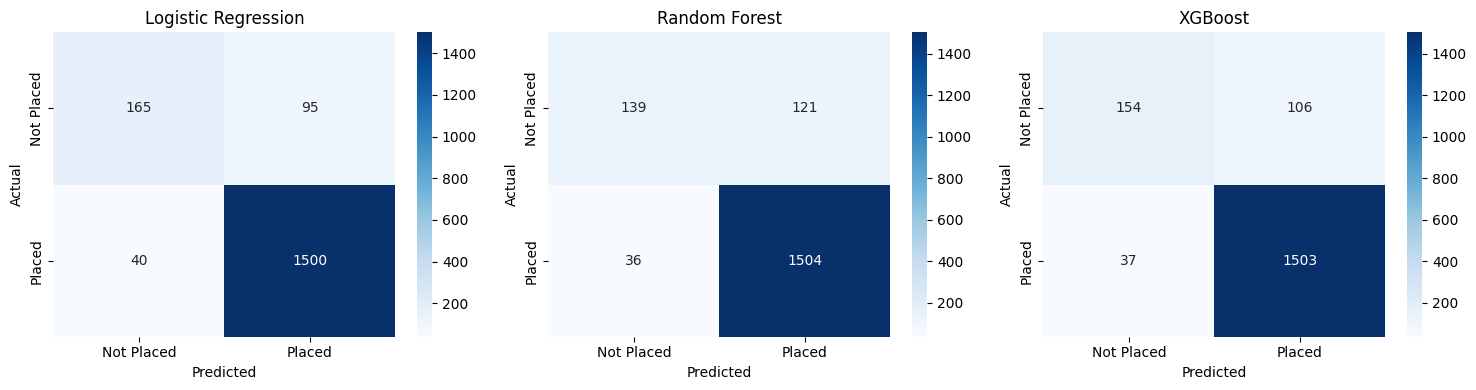

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, res in zip(axes, [res_lr, res_rf, res_xgb]):
    cm = confusion_matrix(y_test, res['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Placed','Placed'],
                yticklabels=['Not Placed','Placed'])
    ax.set_title(res['Model'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

In [12]:
best_name = "XGBoost"
best_model = res_xgb['_fitted']
joblib.dump(best_model, data_dir + 'best_clf_model.pkl')

results_df.to_csv(data_dir + 'classification_results.csv', index=False)

print(f"✅ XGBoost model has been saved as the best model.")
print(f"✅ Results table saved as classification_results.csv")

✅ XGBoost model has been saved as the best model.
✅ Results table saved as classification_results.csv
